<a href="https://colab.research.google.com/github/SLCFLAB/Fintech2026-1/blob/main/DL_day6/6_1_RNN_and_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RNN and LSTM

In [18]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, header=0, parse_dates=[0], index_col=0)

In [3]:
df

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


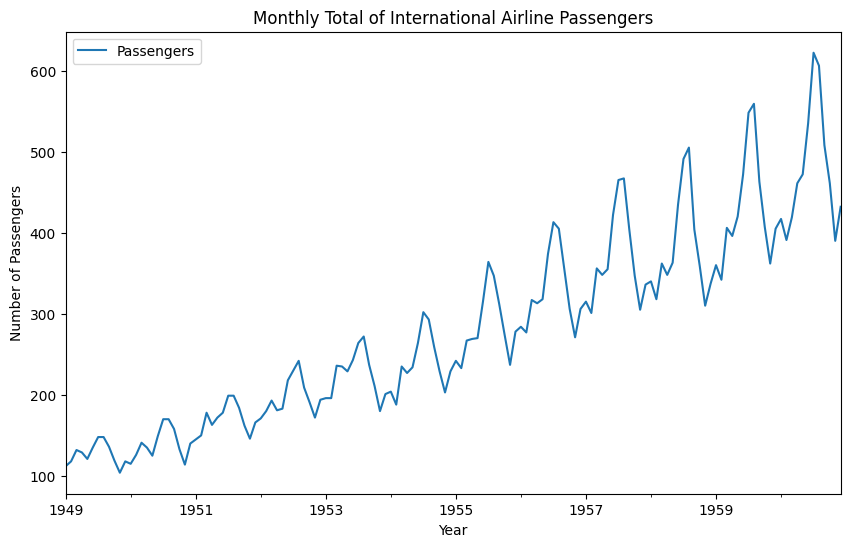

In [4]:
df.plot(figsize=(10,6))
plt.title("Monthly Total of International Airline Passengers")
plt.xlabel("Year")
plt.ylabel("Number of Passengers")
plt.show()

In [5]:
scaler = MinMaxScaler(feature_range=(-1, 1))
data_scaled = scaler.fit_transform(df.values.reshape(-1, 1))

In [6]:
def create_sequences(data, seq_length):
    sequences = []
    labels = []
    for i in range(len(data) - seq_length):
        seq = data[i:i+seq_length]
        label = data[i+seq_length]
        sequences.append(seq)
        labels.append(label)
    return np.array(sequences), np.array(labels)


In [7]:
class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

In [24]:
input_size, hidden_size, output_size = 1, 3, 1

seq_length = 12
X, y = create_sequences(data_scaled, seq_length)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

model_rnn = RNNModel(input_size, hidden_size, output_size)
model_lstm = LSTMModel(input_size, hidden_size, output_size)

criterion = nn.MSELoss()
optimizer_rnn = torch.optim.Adam(model_rnn.parameters(), lr=1e-3)
optimizer_lstm = torch.optim.Adam(model_lstm.parameters(), lr=1e-3)

In [9]:
def train_model(model, optimizer, X_train, y_train, epochs=100):
    print('')
    model.train()
    train_losses = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        y_pred = model(X_train)

        loss = criterion(y_pred, y_train)
        train_losses.append(loss.item())

        loss.backward()
        optimizer.step()

        if (epoch + 1) % 200 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

    return model, train_losses

In [10]:
model_rnn, train_losses_rnn = train_model(model_rnn, optimizer_rnn, X_train, y_train, epochs=5000)
model_lstm, train_losses_lstm = train_model(model_lstm, optimizer_lstm, X_train, y_train, epochs=5000)

model_rnn.eval()
model_lstm.eval()

y_pred_rnn = model_rnn(X_test).detach()
y_pred_lstm = model_lstm(X_test).detach()

y_pred_rnn = scaler.inverse_transform(y_pred_rnn.numpy().reshape(-1, 1))
y_pred_lstm = scaler.inverse_transform(y_pred_lstm.numpy().reshape(-1, 1))
y_test = scaler.inverse_transform(y_test.numpy().reshape(-1, 1))
y_train = scaler.inverse_transform(y_train.numpy().reshape(-1, 1))


Epoch [200/5000], Loss: 0.1089
Epoch [400/5000], Loss: 0.0255
Epoch [600/5000], Loss: 0.0167
Epoch [800/5000], Loss: 0.0159
Epoch [1000/5000], Loss: 0.0150
Epoch [1200/5000], Loss: 0.0142
Epoch [1400/5000], Loss: 0.0134
Epoch [1600/5000], Loss: 0.0128
Epoch [1800/5000], Loss: 0.0122
Epoch [2000/5000], Loss: 0.0117
Epoch [2200/5000], Loss: 0.0113
Epoch [2400/5000], Loss: 0.0110
Epoch [2600/5000], Loss: 0.0107
Epoch [2800/5000], Loss: 0.0104
Epoch [3000/5000], Loss: 0.0102
Epoch [3200/5000], Loss: 0.0100
Epoch [3400/5000], Loss: 0.0096
Epoch [3600/5000], Loss: 0.0091
Epoch [3800/5000], Loss: 0.0084
Epoch [4000/5000], Loss: 0.0077
Epoch [4200/5000], Loss: 0.0072
Epoch [4400/5000], Loss: 0.0065
Epoch [4600/5000], Loss: 0.0059
Epoch [4800/5000], Loss: 0.0054
Epoch [5000/5000], Loss: 0.0046

Epoch [200/5000], Loss: 0.1110
Epoch [400/5000], Loss: 0.0841
Epoch [600/5000], Loss: 0.0391
Epoch [800/5000], Loss: 0.0219
Epoch [1000/5000], Loss: 0.0213
Epoch [1200/5000], Loss: 0.0206
Epoch [1400/50

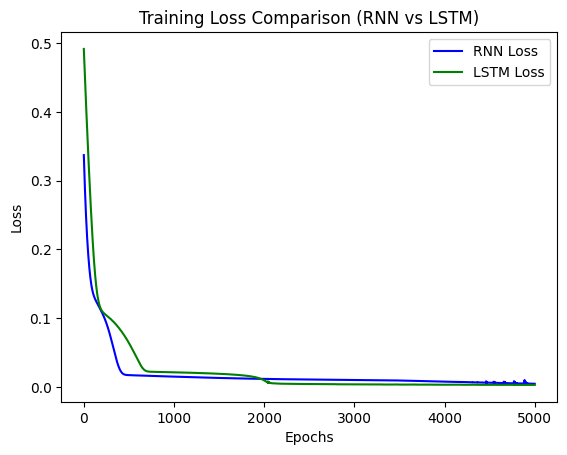

In [11]:
plt.plot(train_losses_rnn, label="RNN Loss", color='blue')
plt.plot(train_losses_lstm, label="LSTM Loss", color='green')
plt.title("Training Loss Comparison (RNN vs LSTM)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

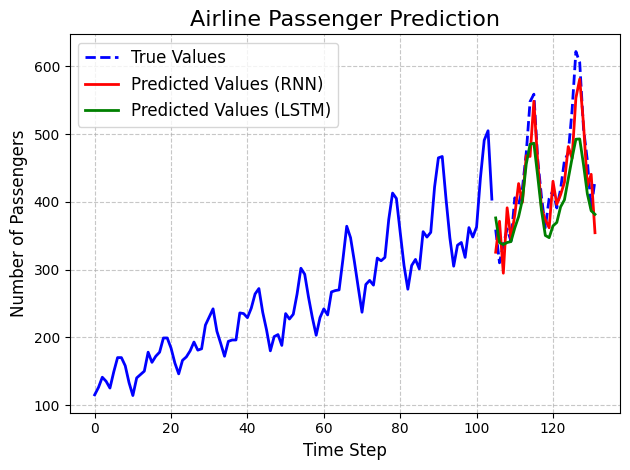

In [12]:
plt.plot(np.arange(0, len(y_train)), y_train, color='blue', linestyle='-', linewidth=2)
plt.plot(np.arange(len(y_train), len(y_train) + len(y_test)), y_test, label='True Values',  linestyle='--', color='blue', linewidth=2)
plt.plot(np.arange(len(y_train), len(y_train) + len(y_test)), y_pred_rnn, label='Predicted Values (RNN)', color='red', linestyle='-', linewidth=2)
plt.plot(np.arange(len(y_train), len(y_train) + len(y_test)), y_pred_lstm, label='Predicted Values (LSTM)', color='green', linestyle='-', linewidth=2)

plt.grid(True, linestyle='--', alpha=0.7)
plt.title("Airline Passenger Prediction", fontsize=16)
plt.xlabel("Time Step", fontsize=12)
plt.ylabel("Number of Passengers", fontsize=12)

plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

In [17]:
rnn_mse = np.mean((y_test - y_pred_rnn) ** 2)
rnn_mae = np.mean(np.abs(y_test - y_pred_rnn))

lstm_mse = np.mean((y_test - y_pred_lstm) ** 2)
lstm_mae = np.mean(np.abs(y_test - y_pred_lstm))

print(f"RNN  Test MSE: {rnn_mse:.4f}")
print(f"RNN  Test MAE: {rnn_mae:.4f}")
print(f"LSTM Test MSE: {lstm_mse:.4f}")
print(f"LSTM Test MAE: {lstm_mae:.4f}")

RNN  Test MSE: 1494.7921
RNN  Test MAE: 30.5104
LSTM Test MSE: 2563.6172
LSTM Test MAE: 39.9452


In [25]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

def regression_metrics(y_true, y_pred, scaler):
    y_true_inv = scaler.inverse_transform(y_true.detach().cpu().numpy())
    y_pred_inv = scaler.inverse_transform(y_pred.detach().cpu().numpy())

    mse = np.mean((y_true_inv - y_pred_inv) ** 2)
    mae = np.mean(np.abs(y_true_inv - y_pred_inv))
    return mse, mae

In [28]:
# 여러 seed로 반복 실험
X, y = create_sequences(data_scaled, seq_length)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

seeds = [0, 1, 2, 3, 4]
results = []

for seed in seeds:
    set_seed(seed)

    model_rnn = RNNModel(input_size=1, hidden_size=3, output_size=1)
    model_lstm = LSTMModel(input_size=1, hidden_size=3, output_size=1)
    optimizer_rnn = torch.optim.Adam(model_rnn.parameters(), lr=1e-3)
    optimizer_lstm = torch.optim.Adam(model_lstm.parameters(), lr=1e-3)
    model_rnn, train_losses_rnn = train_model(model_rnn, optimizer_rnn, X_train, y_train, epochs=3000)
    model_lstm, train_losses_lstm = train_model(model_lstm, optimizer_lstm, X_train, y_train, epochs=3000)

    model_rnn.eval()
    model_lstm.eval()

    with torch.no_grad():
        y_pred_rnn = model_rnn(X_test)
        y_pred_lstm = model_lstm(X_test)

    rnn_mse, rnn_mae = regression_metrics(y_test, y_pred_rnn, scaler)
    lstm_mse, lstm_mae = regression_metrics(y_test, y_pred_lstm, scaler)

    results.append({
        "seed": seed,
        "RNN_MSE": rnn_mse,
        "RNN_MAE": rnn_mae,
        "LSTM_MSE": lstm_mse,
        "LSTM_MAE": lstm_mae
    })


Epoch [200/3000], Loss: 0.6174
Epoch [400/3000], Loss: 0.1787
Epoch [600/3000], Loss: 0.1177
Epoch [800/3000], Loss: 0.1100
Epoch [1000/3000], Loss: 0.0982
Epoch [1200/3000], Loss: 0.0731
Epoch [1400/3000], Loss: 0.0345
Epoch [1600/3000], Loss: 0.0175
Epoch [1800/3000], Loss: 0.0154
Epoch [2000/3000], Loss: 0.0144
Epoch [2200/3000], Loss: 0.0136
Epoch [2400/3000], Loss: 0.0130
Epoch [2600/3000], Loss: 0.0124
Epoch [2800/3000], Loss: 0.0120
Epoch [3000/3000], Loss: 0.0116

Epoch [200/3000], Loss: 0.1086
Epoch [400/3000], Loss: 0.0447
Epoch [600/3000], Loss: 0.0249
Epoch [800/3000], Loss: 0.0229
Epoch [1000/3000], Loss: 0.0217
Epoch [1200/3000], Loss: 0.0207
Epoch [1400/3000], Loss: 0.0197
Epoch [1600/3000], Loss: 0.0186
Epoch [1800/3000], Loss: 0.0174
Epoch [2000/3000], Loss: 0.0161
Epoch [2200/3000], Loss: 0.0148
Epoch [2400/3000], Loss: 0.0135
Epoch [2600/3000], Loss: 0.0121
Epoch [2800/3000], Loss: 0.0105
Epoch [3000/3000], Loss: 0.0092

Epoch [200/3000], Loss: 0.0201
Epoch [400/300

In [29]:
# 결과 표로 정리
results_df = pd.DataFrame(results)
print(results_df)

print("\n평균 성능")
summary = results_df[["RNN_MSE", "RNN_MAE", "LSTM_MSE", "LSTM_MAE"]].agg(["mean", "std"])
print(summary.round(4))
'''
12 step(1년)마다 반복되는 시계열 패턴은 비교적 단순해서 LSTM의 장점(long-term dependency를 학습)이 드러나기 어렵다.
데이터가 매우 작고, hidden size도 작기 때문에 복잡한 LSTM보다 단순한 RNN이 오히려 더 잘 일반화했을 가능성이 크다.
'''

   seed      RNN_MSE    RNN_MAE     LSTM_MSE   LSTM_MAE
0     0  2146.134033  39.618065  3140.859131  43.404053
1     1  1322.313477  29.646814  2036.527466  32.239414
2     2  2258.697754  41.048420  2134.477051  35.190376
3     3  2939.283447  42.930332  3290.660400  44.358643
4     4  2708.690674  41.996746  2732.367188  44.162403

평균 성능
        RNN_MSE  RNN_MAE   LSTM_MSE  LSTM_MAE
mean  2275.0239  39.0481  2666.9783   39.8710
std    623.2664   5.3962   569.8342    5.7268
